# ===============================
# Sales Analysis Project
# Author: Durga Prasad Keshri
# ===============================

In [2]:
# 1. Import Libraries
import pandas as pd  
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:

# 2. Load Dataset
df=pd.read_csv("raw_sales_data.csv")
# print("---raw---")
# print(df.head())

In [5]:
# 3. Data Cleaning
df["Customer_Name"]=df["Customer_Name"].str.strip().str.title()
df["City"]=df["City"].str.strip().str.title()
# print("---clean---")
print(df.head())
print(df.info())
df["Order_Date"]=pd.to_datetime(df["Order_Date"],format="%d-%m-%Y")

  Order_ID  Order_Date Customer_Name     City        State Product_Category  \
0  ORD1001  01-01-2024   Ajay Sharma    Surat  Maharashtra      Electronics   
1  ORD1002  02-01-2024   Smita Patel    Patna  Maharashtra      Electronics   
2  ORD1003  03-01-2024    Amit Singh  Kolkata        Delhi      Electronics   
3  ORD1004  04-01-2024   Karan Yadav  Chennai   Tamil Nadu      Electronics   
4  ORD1005  05-01-2024   Priya Singh     Pune  Maharashtra      Accessories   

   Product_Name  Quantity  Unit_Price  Discount Payment_Mode Sales_Channel  
0  Mobile Phone         1       18000       500          UPI        Online  
1        Laptop         1       55000      2000  Credit Card       Offline  
2        Tablet         2       22000      1000          UPI        Online  
3        Laptop         1       58000      1500   Debit Card       Offline  
4     Earphones         3        1500         0          UPI        Online  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0

In [6]:
# 4. Feature Engineering
df["Year"]=df["Order_Date"].dt.year
df["Month"]=df["Order_Date"].dt.month

In [7]:
# Total sales 
df["Sales"]=df["Quantity"]*df["Unit_Price"]-df["Discount"]
total_sales=df["Sales"].sum()
print("Total Sales:",total_sales)

Total Sales: 800500


In [8]:

# Sales by Year 
sales_by_year=df.groupby("Year")["Sales"].sum()
print(sales_by_year)


Year
2024    800500
Name: Sales, dtype: int64


In [10]:

# Top 10 product by sales_by_year
Top_product=df.groupby("Product_Name")["Sales"].sum().sort_values(ascending=False).head(10)
print(Top_product)

Product_Name
Laptop          236500
Tablet          216000
Mobile Phone    214000
Earphones        80500
Smart Watch      53500
Name: Sales, dtype: int64


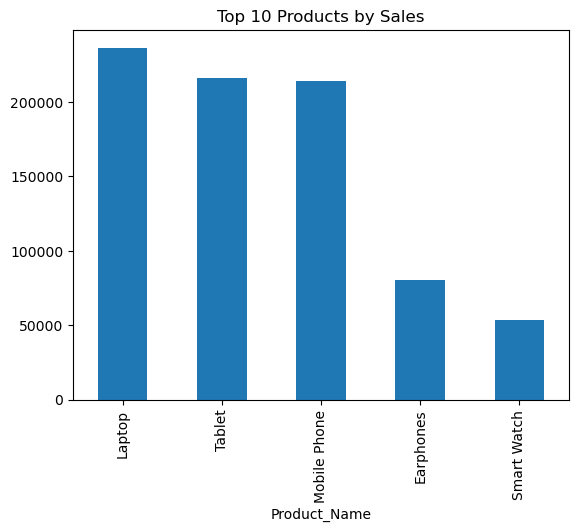

In [11]:
#Visualization
Top_product.plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.show()

In [12]:

# Sales by Region 
sales_by_region=df.groupby("City")["Sales"].sum().sort_values(ascending=False)
print(sales_by_region)

City
Chennai    284500
Mumbai     126500
Delhi       87000
Kolkata     85000
Pune        78000
Surat       75000
Patna       64500
Name: Sales, dtype: int64


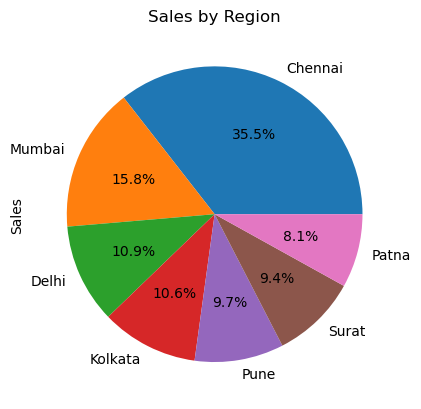

In [13]:
#Visualization
sales_by_region.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Region")
plt.show()